# Paired A/B Model Comparison via Pólya–Gamma Gibbs Sampling

This notebook implements **exact** Bayesian logistic regression for paired binary scores
using the **Pólya–Gamma data-augmentation** scheme (Polson, Scott & Windle, 2013).

### Use simulated data

In [3]:
import numpy as np
from pathlib import Path

from bayesprop.resources.bayes_paired import PairedBayesPropTest
from bayesprop.resources.bayes_paired_laplace import _format_bf
from bayesprop.utils.utils import simulate_paired_scores

IMG_DIR = Path("../../docs/mkdocs/docs/images/paired-gibbs")
IMG_DIR.mkdir(parents=True, exist_ok=True)

# Simulate paired binary data (same DGP as Laplace notebook)
sim = simulate_paired_scores(N=250, theta_A=0.69, theta_B=0.50, sigma_theta=0.0, seed=42)

y_A_sim = sim.y_A
y_B_sim = sim.y_B

print(f"True θ_A = {sim.theta_A:.2f},  θ_B = {sim.theta_B:.2f},  Δ = {sim.theta_A - sim.theta_B:.2f}")
print(f"Observed rates: A = {y_A_sim.mean():.3f},  B = {y_B_sim.mean():.3f}")
print(f"\n(Logit-scale: μ = {sim.true_params.mu:.4f}, δ_A = {sim.true_params.delta_A:.4f})")

True θ_A = 0.69,  θ_B = 0.50,  Δ = 0.19
Observed rates: A = 0.692,  B = 0.476

(Logit-scale: μ = 0.0000, δ_A = 0.8001)


In [4]:
# Fit PG model using the unified facade with method="pg"
# (defaults: n_iter=1000, burn_in=200, n_chains=2 — block-conjugate Gibbs
#  reaches R-hat ≈ 1.00 by ~200 iterations.)
pg_model = PairedBayesPropTest(method="pg", seed=42).fit(y_A_sim, y_B_sim)

s = pg_model.summary
print(f"θ_A posterior mean = {s.theta_A_mean:.4f}")
print(f"θ_B posterior mean = {s.theta_B_mean:.4f}")
print(f"\nMean Δ (θ_A − θ_B) = {s.mean_delta:+.4f}")
print(f"95% CI = [{s.ci_95.lower:.4f}, {s.ci_95.upper:.4f}]")
print(f"P(A > B) = {s.p_A_greater_B:.4f}")

# ── Unified decision ─────────────────────────────────────────────────
d_pg = pg_model.decide()
bf_pg = d_pg.bayes_factor
print("\n--- Unified Decision (PG Gibbs) ---")
print(f"  Bayes Factor:  BF₁₀ = {bf_pg.BF_10:.2f}  → {bf_pg.decision}")
print(f"  Posterior Null: P(H₀|D) = {d_pg.posterior_null.p_H0:.4f}  → {d_pg.posterior_null.decision}")
print(f"  ROPE:          {d_pg.rope.decision}  ({d_pg.rope.pct_in_rope:.1%} in ROPE)")

delta_samples = pg_model.delta_A_samples
mu_samples = pg_model.samples[:, 0]

display(pg_model.trace_summary)

θ_A posterior mean = 0.6875
θ_B posterior mean = 0.4797

Mean Δ (θ_A − θ_B) = +0.2078
95% CI = [0.1234, 0.2886]
P(A > B) = 1.0000

--- Unified Decision (PG Gibbs) ---
  Bayes Factor:  BF₁₀ = 17080962.75  → Reject H0
  Posterior Null: P(H₀|D) = 0.0000  → Reject H0
  ROPE:          Reject H0 — A practically better  (0.0% in ROPE)


,mean,sd,hdi_3%,hdi_97%,R-hat,ESS
delta_A,0.873549,0.183987,0.519095,1.215840,0.999931,1392.527151
mu,-0.081618,0.125995,-0.318816,0.153042,0.999410,1506.691305


## Compare PG vs Laplace posteriors

In [5]:
# Fit the same data with the Laplace model for comparison
laplace_model = PairedBayesPropTest(seed=42, n_samples=2000).fit(y_A_sim, y_B_sim)

laplace_delta = laplace_model.delta_A_samples
laplace_mu = laplace_model.laplace["mu_samples"]

print("PG Gibbs vs Laplace — posterior summary (probability scale)")
print("=" * 60)
print(f"{'':20} {'PG Gibbs':>15} {'Laplace':>15}")
print("-" * 60)
print(f"{'θ_A mean':20} {pg_model.summary.theta_A_mean:>15.4f} {laplace_model.summary.theta_A_mean:>15.4f}")
print(f"{'θ_B mean':20} {pg_model.summary.theta_B_mean:>15.4f} {laplace_model.summary.theta_B_mean:>15.4f}")
print(f"{'Mean Δ':20} {pg_model.summary.mean_delta:>15.4f} {laplace_model.summary.mean_delta:>15.4f}")
print(f"{'P(A > B)':20} {pg_model.summary.p_A_greater_B:>15.4f} {laplace_model.summary.p_A_greater_B:>15.4f}")
print("=" * 60)
print()
print("Logit-scale parameters")
print("-" * 60)
print(f"{'δ_A mean':20} {delta_samples.mean():>15.4f} {laplace_delta.mean():>15.4f}")
print(f"{'δ_A sd':20} {delta_samples.std():>15.4f} {laplace_delta.std():>15.4f}")
print(f"{'μ mean':20} {mu_samples.mean():>15.4f} {laplace_mu.mean():>15.4f}")
print("=" * 60)

PG Gibbs vs Laplace — posterior summary (probability scale)
                            PG Gibbs         Laplace
------------------------------------------------------------
θ_A mean                      0.6875          0.6870
θ_B mean                      0.4797          0.4802
Mean Δ                        0.2078          0.2068
P(A > B)                      1.0000          1.0000

Logit-scale parameters
------------------------------------------------------------
δ_A mean                      0.8735          0.8693
δ_A sd                        0.1840          0.1834
μ mean                       -0.0816         -0.0795


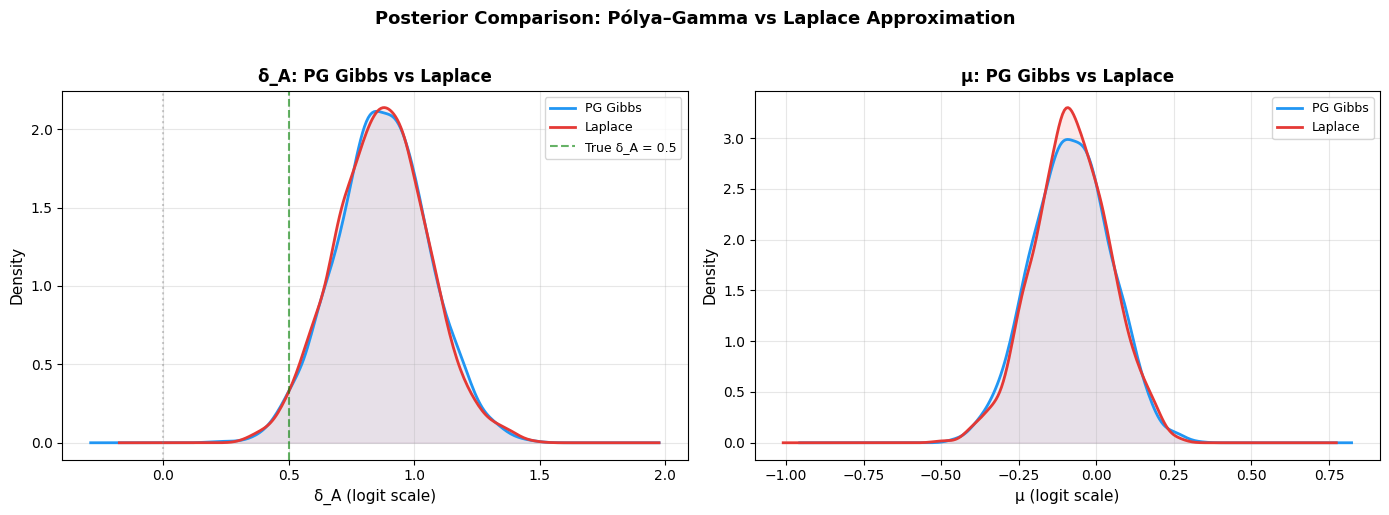

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# δ_A comparison
ax = axes[0]
for samples, label, color in [
    (delta_samples, "PG Gibbs", "#2196F3"),
    (laplace_delta, "Laplace", "#E53935"),
]:
    kde = gaussian_kde(samples)
    x = np.linspace(samples.min() - 0.5, samples.max() + 0.5, 300)
    ax.plot(x, kde(x), linewidth=2, color=color, label=label)
    ax.fill_between(x, kde(x), alpha=0.1, color=color)

ax.axvline(0.5, color="green", ls="--", alpha=0.6, label="True δ_A = 0.5")
ax.axvline(0, color="gray", ls=":", alpha=0.4)
ax.set_xlabel("δ_A (logit scale)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("δ_A: PG Gibbs vs Laplace", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# μ comparison
ax = axes[1]
for samples, label, color in [
    (mu_samples, "PG Gibbs", "#2196F3"),
    (laplace_mu, "Laplace", "#E53935"),
]:
    kde = gaussian_kde(samples)
    x = np.linspace(samples.min() - 0.5, samples.max() + 0.5, 300)
    ax.plot(x, kde(x), linewidth=2, color=color, label=label)
    ax.fill_between(x, kde(x), alpha=0.1, color=color)

ax.set_xlabel("μ (logit scale)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("μ: PG Gibbs vs Laplace", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle("Posterior Comparison: Pólya–Gamma vs Laplace Approximation", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(IMG_DIR / "pg_vs_laplace_posterior_comparison.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## MCMC diagnostics

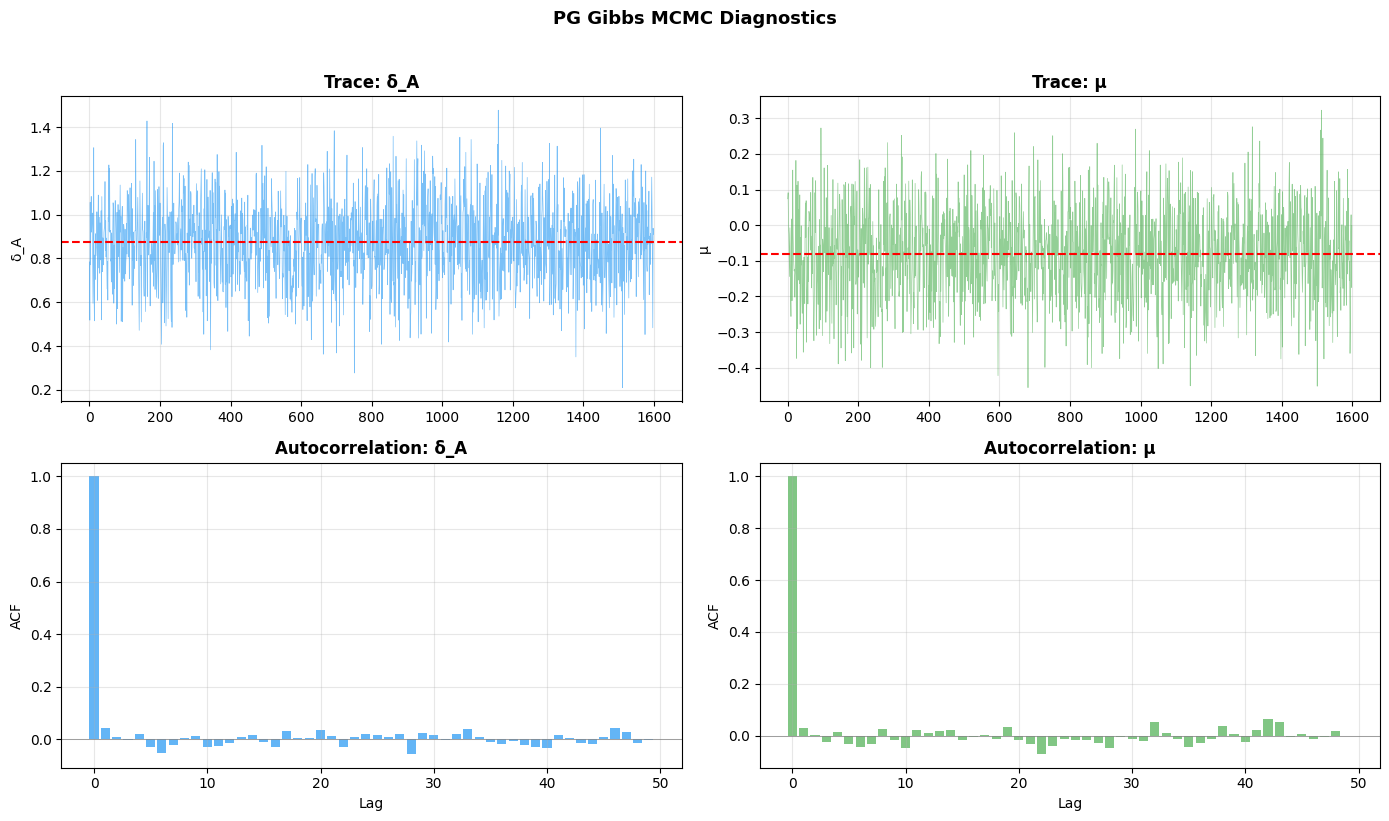

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Trace plots
axes[0, 0].plot(delta_samples, alpha=0.6, linewidth=0.5, color="#2196F3")
axes[0, 0].axhline(delta_samples.mean(), color="red", ls="--", lw=1.5)
axes[0, 0].set_ylabel("δ_A")
axes[0, 0].set_title("Trace: δ_A", fontweight="bold")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(mu_samples, alpha=0.6, linewidth=0.5, color="#4CAF50")
axes[0, 1].axhline(mu_samples.mean(), color="red", ls="--", lw=1.5)
axes[0, 1].set_ylabel("μ")
axes[0, 1].set_title("Trace: μ", fontweight="bold")
axes[0, 1].grid(alpha=0.3)

# Autocorrelation
max_lag = 50
for ax, samples, name, color in [
    (axes[1, 0], delta_samples, "δ_A", "#2196F3"),
    (axes[1, 1], mu_samples, "μ", "#4CAF50"),
]:
    centered = samples - samples.mean()
    acf = np.correlate(centered, centered, mode="full")
    acf = acf[len(acf) // 2 :]
    acf /= acf[0]
    ax.bar(range(max_lag), acf[:max_lag], color=color, alpha=0.7)
    ax.axhline(0, color="gray", ls="-", lw=0.5)
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    ax.set_title(f"Autocorrelation: {name}", fontweight="bold")
    ax.grid(alpha=0.3)

fig.suptitle("PG Gibbs MCMC Diagnostics", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(IMG_DIR / "mcmc_diagnostics_trace_acf.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Savage-Dickey Bayes Factor

We can compute the same Savage-Dickey test using the PG posterior samples:

$$
BF_{01} = \frac{p(\delta_A = 0 \mid D)}{g(0)}
$$

In [8]:
from scipy.stats import norm

# Use decide() for both models
d_laplace = laplace_model.decide()
bf_laplace = d_laplace.bayes_factor

print("Savage-Dickey Bayes Factor comparison")
print("=" * 55)
print(f"{'':20} {'PG Gibbs':>15} {'Laplace':>15}")
print("-" * 55)
print(f"{'Post. density at 0':20} {bf_pg.posterior_density_at_0:>15.4e} {bf_laplace.posterior_density_at_0:>15.4e}")
print(f"{'Prior density at 0':20} {bf_pg.prior_density_at_0:>15.6f} {bf_laplace.prior_density_at_0:>15.6f}")
print(f"{'BF_10':20} {bf_pg.BF_10:>15.2f} {bf_laplace.BF_10:>15.2f}")
print(f"{'log₁₀(BF_10)':20} {np.log10(bf_pg.BF_10):>15.1f} {np.log10(bf_laplace.BF_10):>15.1f}")
print(f"{'BF Decision':20} {bf_pg.decision:>15} {bf_laplace.decision:>15}")
print(f"{'ROPE Decision':20} {d_pg.rope.decision:>15} {d_laplace.rope.decision:>15}")
print("=" * 55)

Savage-Dickey Bayes Factor comparison
                            PG Gibbs         Laplace
-------------------------------------------------------
Post. density at 0        2.3356e-08      2.3503e-05
Prior density at 0          0.398942        0.398942
BF_10                    17080962.75        16974.30
log₁₀(BF_10)                     7.2             4.2
BF Decision                Reject H0       Reject H0
ROPE Decision        Reject H0 — A practically better Reject H0 — A practically better


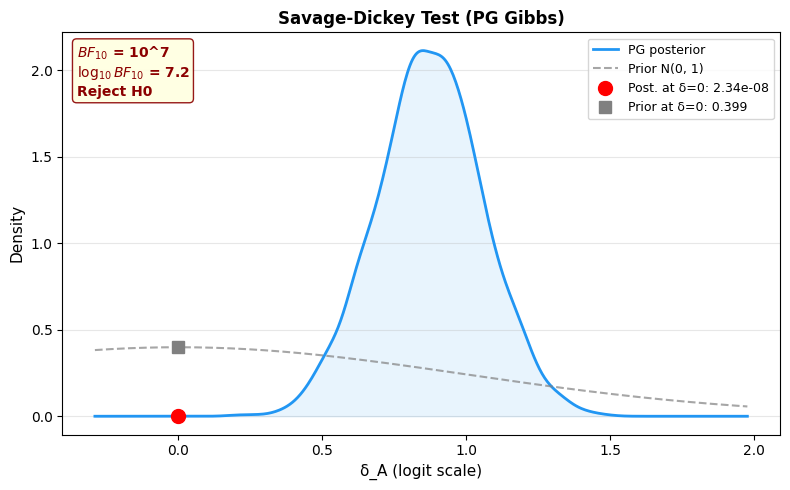

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

kde_pg = gaussian_kde(delta_samples)
x_grid = np.linspace(delta_samples.min() - 0.5, delta_samples.max() + 0.5, 500)

ax.plot(x_grid, kde_pg(x_grid), color="#2196F3", lw=2, label="PG posterior")
ax.fill_between(x_grid, kde_pg(x_grid), alpha=0.1, color="#2196F3")

prior_density = norm.pdf(x_grid, 0, 1.0)
ax.plot(x_grid, prior_density, color="gray", lw=1.5, ls="--", alpha=0.7, label="Prior N(0, 1)")

ax.plot(
    0,
    bf_pg.posterior_density_at_0,
    "o",
    color="red",
    ms=10,
    zorder=5,
    label=f"Post. at δ=0: {bf_pg.posterior_density_at_0:.2e}",
)
ax.plot(
    0,
    bf_pg.prior_density_at_0,
    "s",
    color="gray",
    ms=8,
    zorder=5,
    label=f"Prior at δ=0: {bf_pg.prior_density_at_0:.3f}",
)

bf10_label = _format_bf(bf_pg.BF_10)
log10_bf = np.log10(bf_pg.BF_10)
ax.text(
    0.02,
    0.97,
    f"$BF_{{10}}$ = {bf10_label}\n$\\log_{{10}}BF_{{10}}$ = {log10_bf:.1f}\n{bf_pg.decision}",
    fontsize=10,
    fontweight="bold",
    color="darkred",
    transform=ax.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="darkred", alpha=0.9),
)

ax.set_xlabel("δ_A (logit scale)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Savage-Dickey Test (PG Gibbs)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(IMG_DIR / "savage_dickey_pg_gibbs.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Posterior predictive check

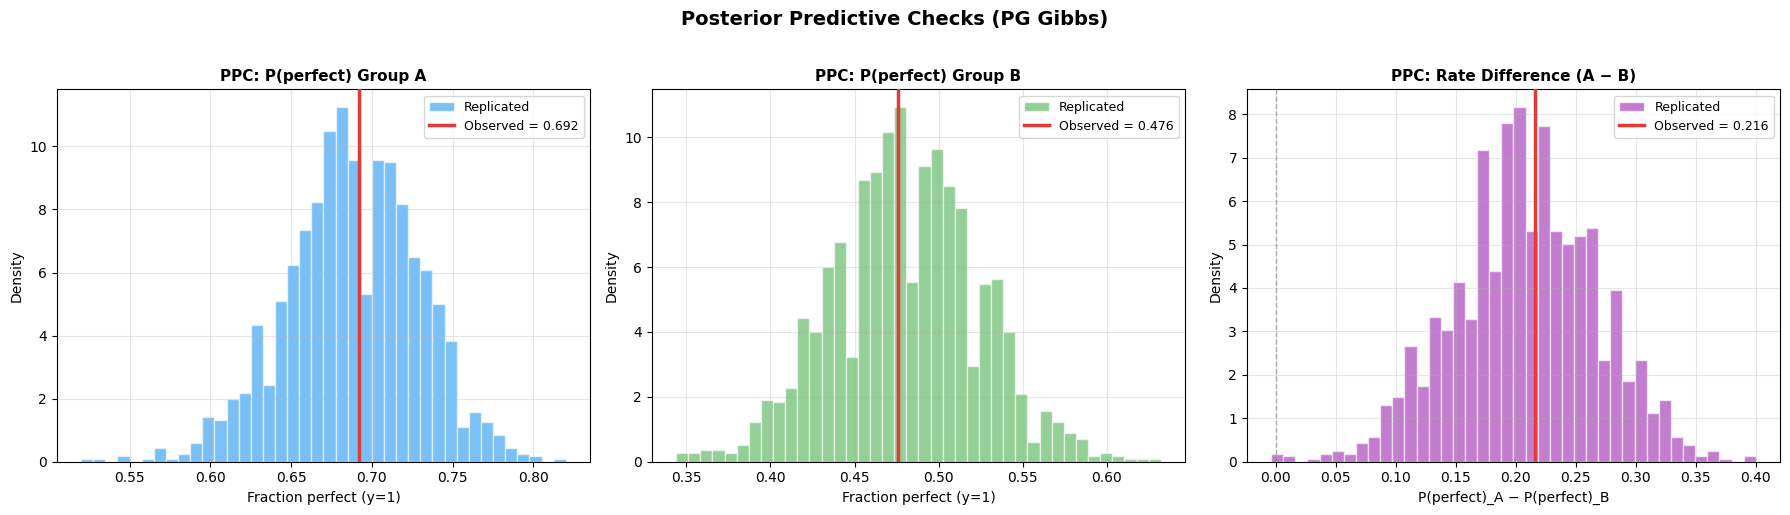

Posterior Predictive p-values (two-sided) — PG Gibbs
Statistic              Observed    p-value     Status
----------------------------------------------------------------------
mean(y_A)                0.6920      0.961         OK
mean(y_B)                0.4760      0.953         OK
mean(y_A-y_B)            0.2160      0.935         OK
std(y_A-y_B)             0.6398      0.110         OK
n_disagree             114.0000      0.115         OK


In [10]:
# ── PPC plots (using class method) ────────────────────────────────────
_show = plt.show
plt.show = lambda: None
pg_model.plot_ppc(seed=42)
plt.savefig(IMG_DIR / "ppc_plots_pg_gibbs.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show = _show
plt.show()

# ── PPC p-values ─────────────────────────────────────────────────────
print("Posterior Predictive p-values (two-sided) — PG Gibbs")
print("=" * 70)
print(f"{'Statistic':<20} {'Observed':>10} {'p-value':>10} {'Status':>10}")
print("-" * 70)

ppc = pg_model.ppc_pvalues(seed=42)
for stat_name, vals in ppc.items():
    print(f"{stat_name:<20} {vals.observed:>10.4f} {vals.p_value:>10.3f} {vals.status:>10}")

print("=" * 70)

## Unified Decision Rule: `model.decide()`

Run all three decision frameworks (Bayes Factor, Posterior Null, ROPE) in a single call and compare PG Gibbs vs Laplace.

In [12]:
print("Unified Decision — PG Gibbs vs Laplace")
print("=" * 70)

for label, m in [("PG Gibbs", pg_model), ("Laplace", laplace_model)]:
    d = m.decide()

    bf = d.bayes_factor
    pn = d.posterior_null
    rp = d.rope

    print(f"\n{label}:")
    print(f"  Bayes Factor:    BF₁₀ = {bf.BF_10:.2f}  → {bf.decision}")
    print(f"  Posterior Null:   P(H₀|D) = {pn.p_H0:.4f}  → {pn.decision}")
    print(f"  ROPE [{rp.rope_lower:.2f}, {rp.rope_upper:.2f}]:  {rp.decision}  ({rp.pct_in_rope:.1%} in ROPE)")

print("\n" + "=" * 70)
print(f"{'Model':<15} {'BF Decision':>15} {'P(H₀) Decision':>18} {'ROPE Decision':>16}")
print("-" * 70)
for label, m in [("PG Gibbs", pg_model), ("Laplace", laplace_model)]:
    d = m.decide()
    print(f"{label:<15} {d.bayes_factor.decision:>15} {d.posterior_null.decision:>18} {d.rope.decision:>16}")
print("=" * 70)

Unified Decision — PG Gibbs vs Laplace

PG Gibbs:
  Bayes Factor:    BF₁₀ = 17080962.75  → Reject H0
  Posterior Null:   P(H₀|D) = 0.0000  → Reject H0
  ROPE [-0.02, 0.02]:  Reject H0 — A practically better  (0.0% in ROPE)

Laplace:
  Bayes Factor:    BF₁₀ = 16974.30  → Reject H0
  Posterior Null:   P(H₀|D) = 0.0001  → Reject H0
  ROPE [-0.02, 0.02]:  Reject H0 — A practically better  (0.0% in ROPE)

Model               BF Decision     P(H₀) Decision    ROPE Decision
----------------------------------------------------------------------
PG Gibbs              Reject H0          Reject H0 Reject H0 — A practically better
Laplace               Reject H0          Reject H0 Reject H0 — A practically better


### Bayes Factor Design Analysis (BFDA) — Sample Size Planning (Paired PG)

For a hypothesised true effect $\Delta = \theta_A - \theta_B$, we simulate many paired
datasets at each sample size and estimate the probability of obtaining *decisive*
evidence via the PG Gibbs + Savage-Dickey framework

In [10]:
import matplotlib.pyplot as plt
import numpy as np

from bayesprop.utils.utils import (
    bfda_power_curve,
    find_n_for_power,
    plot_bfda_power,
    plot_bfda_sensitivity,
)

# ── Use simulated rates as plug-in estimates for the true effect ──────
theta_A_hat = y_A_sim.mean()
theta_B_hat = y_B_sim.mean()

print("Assumed true rates (from simulated data):")
print(f"  θ_A = {theta_A_hat:.3f}")
print(f"  θ_B = {theta_B_hat:.3f}")
print(f"  True Δ = {theta_A_hat - theta_B_hat:.3f} (effect size)")
print()

# ── Compute BFDA power curve (paired PG model) ───────────────────────
sample_sizes = [20, 30, 50, 75, 100, 150, 200, 300, 500]

power_curve_paired = bfda_power_curve(
    theta_A_true=theta_A_hat,
    theta_B_true=theta_B_hat,
    sample_sizes=sample_sizes,
    design="paired",
    decision_rule="bayes_factor",
    bf_threshold=3.0,
    n_sim=200,
    n_iter=1000,
    burn_in=300,
    n_chains=2,
    seed=42,
)

print(f"{'n (per group)':<15} {'P(BF₁₀ > 3)':>12}")
print("-" * 28)
for n, p in power_curve_paired.items():
    print(f"{n:<15} {p:>12.3f}")

n_80 = find_n_for_power(power_curve_paired, 0.80)
print(f"\n→ Estimated n for 80% power: ≈ {n_80:.0f}" if n_80 else "\n→ n for 80% power: > 500")

Assumed true rates (from simulated data):
  θ_A = 0.692
  θ_B = 0.476
  True Δ = 0.216 (effect size)

n (per group)    P(BF₁₀ > 3)
----------------------------
20                     0.045
30                     0.085
50                     0.125
75                     0.190
100                    0.285
150                    0.430
200                    0.690
300                    0.865
500                    0.990

→ Estimated n for 80% power: ≈ 263


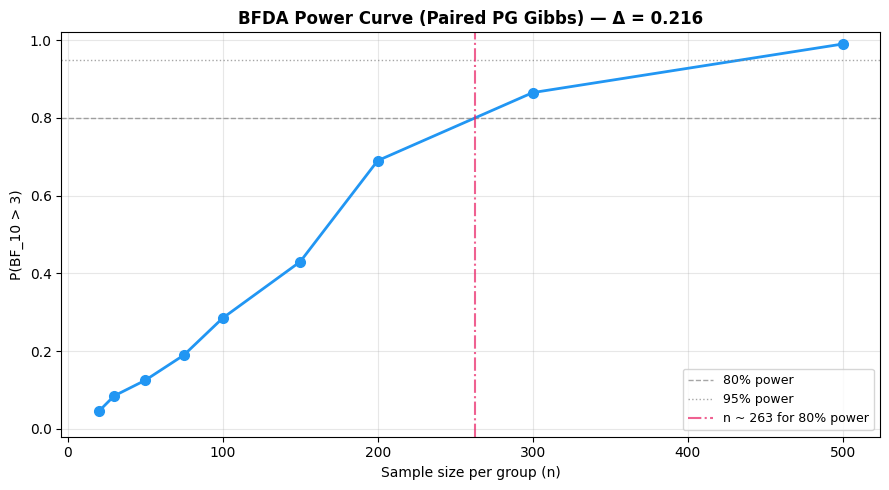

In [11]:
fig = plot_bfda_power(
    power_curve_paired,
    theta_A_hat,
    theta_B_hat,
    title=f"BFDA Power Curve (Paired PG Gibbs) — Δ = {theta_A_hat - theta_B_hat:.3f}",
)
fig.savefig(IMG_DIR / "bfda_power_curve_paired_pg.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

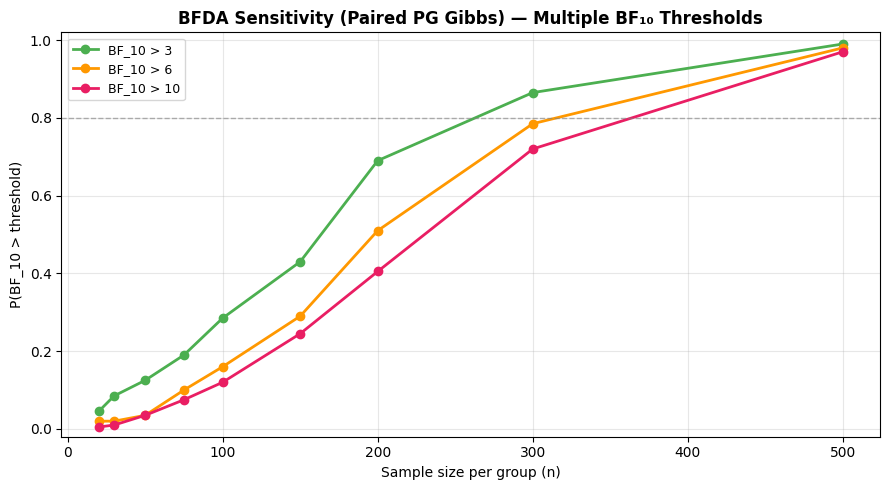

In [12]:
fig = plot_bfda_sensitivity(
    theta_A_true=theta_A_hat,
    theta_B_true=theta_B_hat,
    sample_sizes=sample_sizes,
    thresholds=[3.0, 6.0, 10.0],
    n_sim=200,
    seed=42,
    design="paired",
    title="BFDA Sensitivity (Paired PG Gibbs) — Multiple BF₁₀ Thresholds",
)
fig.savefig(IMG_DIR / "bfda_sensitivity_pg_gibbs.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Hierarchical PG Gibbs — Learning the prior scales

Instead of fixing the prior variances $\sigma^2_\mu$ and $\sigma^2_\delta$, we place
**Inverse-Gamma hyperpriors** on them and let the data learn the appropriate
regularisation:

$$
\sigma^2_\mu \sim \text{IG}(a_\mu, b_\mu), \quad
\sigma^2_\delta \sim \text{IG}(a_\delta, b_\delta)
$$

The Gibbs sampler adds two conjugate IG updates per iteration. The
Savage-Dickey Bayes factor automatically switches to the marginal
Student-$t$ prior on $\delta_A$ induced by the IG hyperprior.

In [13]:
# ── Hierarchical PG Gibbs ─────────────────────────────────────────────
pg_hier = PairedBayesPropTest(
    method="pg",
    seed=42,
    n_iter=2000,
    burn_in=500,
    n_chains=4,
    hyperprior_mu=(2.0, 1.0),      # IG(2, 1) on σ²_μ
    hyperprior_delta=(2.0, 1.0),   # IG(2, 1) on σ²_δ
).fit(y_A_sim, y_B_sim)

pg_hier.print_summary()
display(pg_hier.trace_summary)

PG Gibbs posterior summary (Paired)
  θ_A  mean=0.6858  [n_A=250, k_A=173]
  θ_B  mean=0.4828  [n_B=250, k_B=119]
  Mean Δ (θ_A − θ_B):  0.2030
  95% CI:              [0.1220, 0.2846]
  P(A > B):            1.0000
  Verdict:             A wins

Learned prior scales (hierarchical)
  σ_μ   posterior mean=0.7559  95% CI=[0.3978, 1.5700]
  σ_δ   posterior mean=0.8800  95% CI=[0.4590, 1.8282]

MCMC diagnostics
  Chains: 4, Iterations: 2000, Burn-in: 500
  Total post-warmup samples: 6000
  mu: R-hat=1.0001, ESS=5776  OK
  delta_A: R-hat=1.0000, ESS=5073  OK

Savage-Dickey Bayes Factor: H0 (Δ = 0) vs H1 (Δ ≠ 0)
  Prior  density at δ=0: 0.530330
  Post.  density at δ=0: 4.06e-17
  BF_01 (for H0):        10^-16
  BF_10 (against H0):    10^16
  log₁₀(BF_10):          16.1
  → Decisive evidence against H0
  → Decision: Reject H0

Posterior model probabilities (prior P(H0) = 0.5)
  P(H0|data): 7.65e-17
  P(H1|data): 1.000000

Posterior Predictive p-values
  Statistic              Observed    p-val

,mean,sd,hdi_3%,hdi_97%,R-hat,ESS
delta_A,0.852892,0.181267,0.517142,1.193914,1.000038,5073.264226
mu,-0.068995,0.124170,-0.304084,0.158770,1.000135,5775.533627


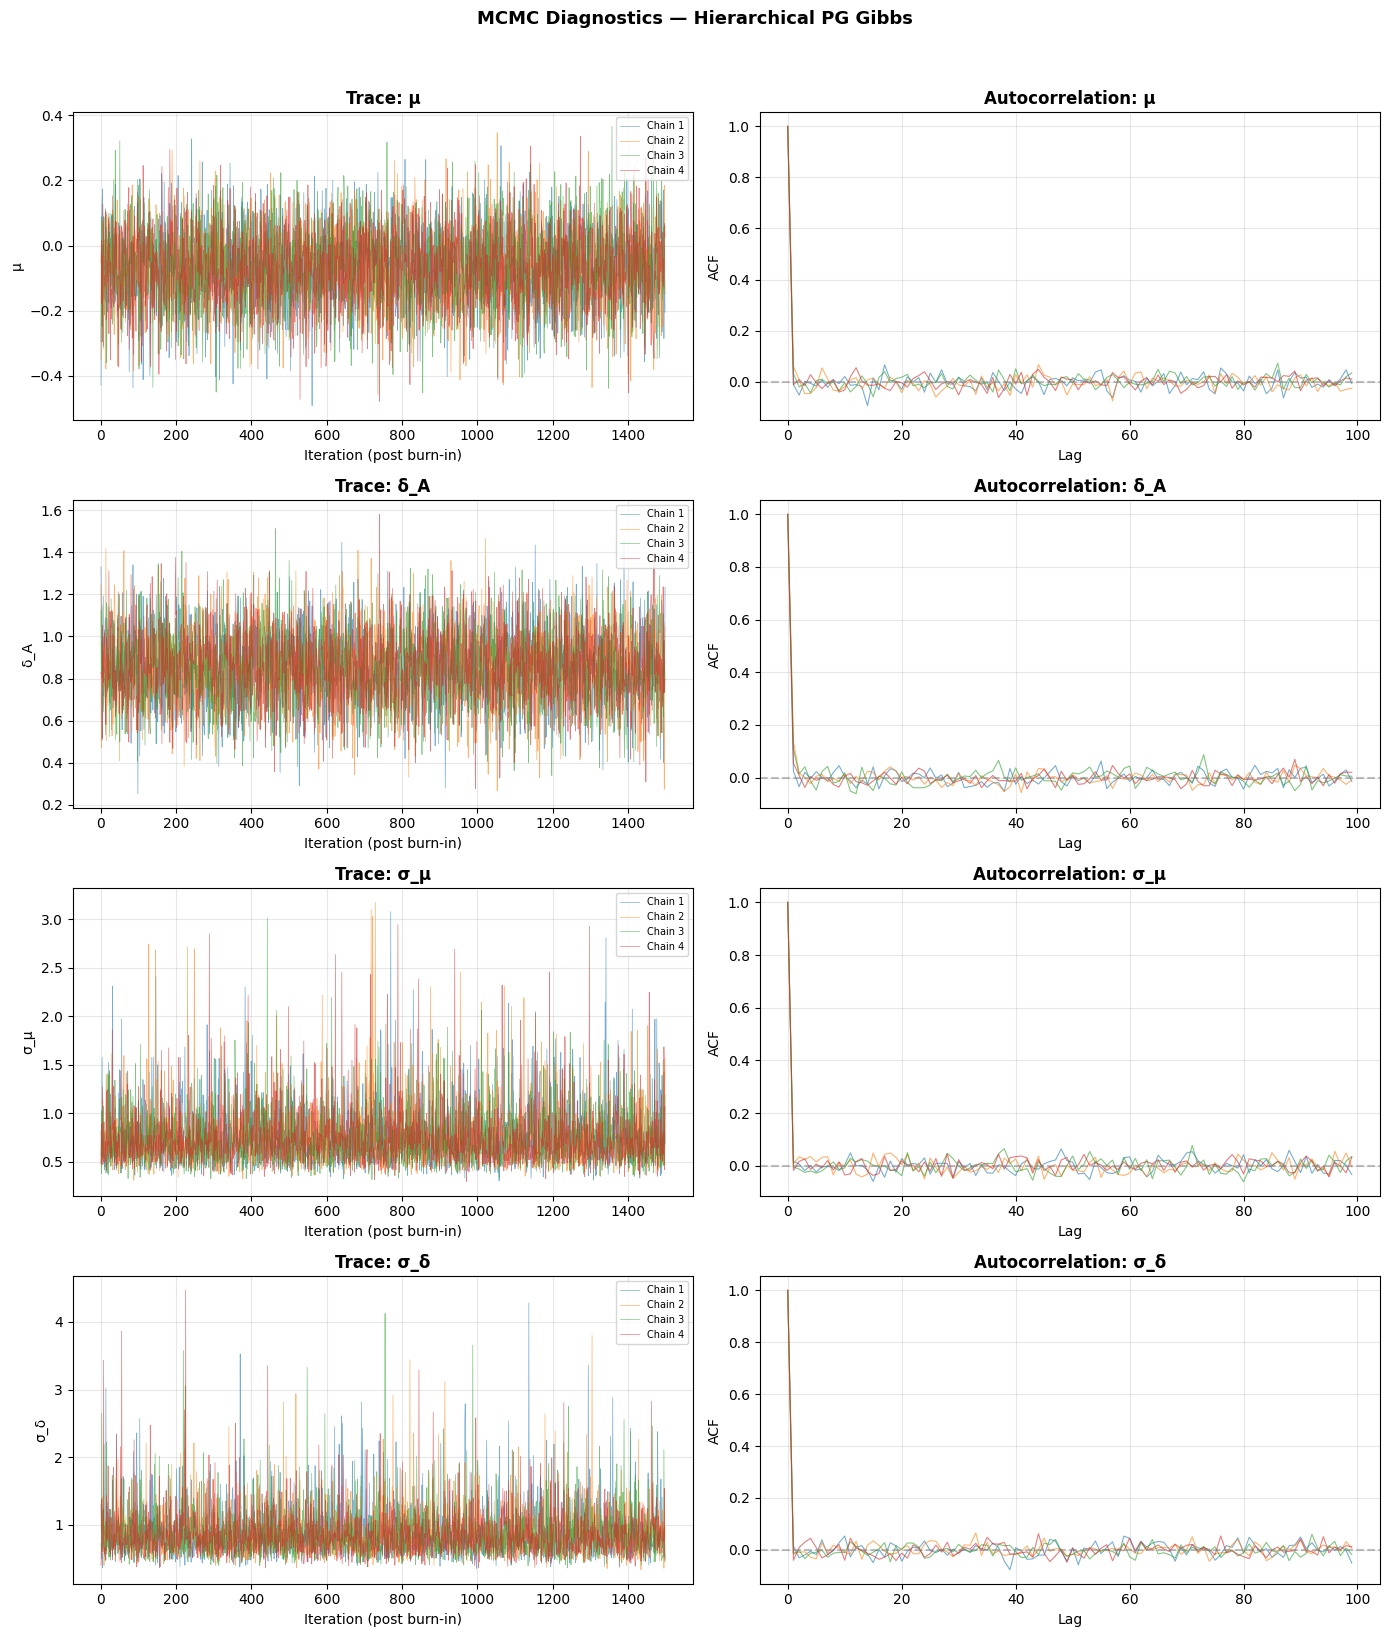

In [14]:
# ── Trace + ACF (now includes σ_μ, σ_δ rows) ────────────────────────
_show = plt.show
plt.show = lambda: None
pg_hier.plot_trace(title="MCMC Diagnostics — Hierarchical PG Gibbs")
plt.savefig(IMG_DIR / "mcmc_diagnostics_hierarchical_pg.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show = _show
plt.show()

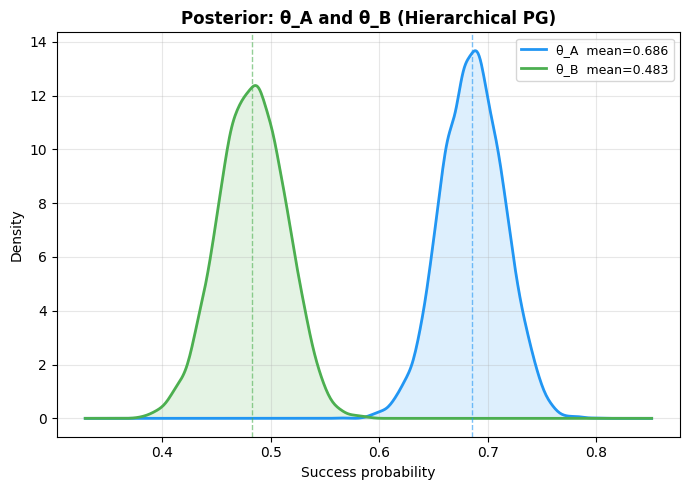

In [15]:
# ── Posterior KDEs (θ_A, θ_B on probability scale) ───────────────────
_show = plt.show
plt.show = lambda: None
pg_hier.plot_posteriors(title="Posterior: θ_A and θ_B (Hierarchical PG)")
plt.savefig(IMG_DIR / "posteriors_hierarchical_pg.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show = _show
plt.show()

In [16]:
# ── Savage-Dickey BF (now uses Student-t marginal prior) ─────────────
d_hier = pg_hier.decide()
bf_hier = d_hier.bayes_factor

print("Hierarchical PG Gibbs — Unified Decision")
print("=" * 60)
print(f"  Bayes Factor:    BF₁₀ = {bf_hier.BF_10:.2f}  → {bf_hier.decision}")
print(f"  Posterior Null:   P(H₀|D) = {d_hier.posterior_null.p_H0:.4f}  → {d_hier.posterior_null.decision}")
print(f"  ROPE:            {d_hier.rope.decision}  ({d_hier.rope.pct_in_rope:.1%} in ROPE)")
print("=" * 60)

Hierarchical PG Gibbs — Unified Decision
  Bayes Factor:    BF₁₀ = 13066785917847526.00  → Reject H0
  Posterior Null:   P(H₀|D) = 0.0000  → Reject H0
  ROPE:            Reject H0 — A practically better  (0.0% in ROPE)


In [18]:
# ── Fixed-prior vs Hierarchical comparison ────────────────────────────
print("Fixed-prior vs Hierarchical PG Gibbs")
print("=" * 70)
print(f"{'':25} {'Fixed':>18} {'Hierarchical':>18}")
print("-" * 70)

s_fix = pg_model.summary
s_hie = pg_hier.summary

print(f"{'θ_A mean':25} {s_fix.theta_A_mean:>18.4f} {s_hie.theta_A_mean:>18.4f}")
print(f"{'θ_B mean':25} {s_fix.theta_B_mean:>18.4f} {s_hie.theta_B_mean:>18.4f}")
print(f"{'Mean Δ (θ_A − θ_B)':25} {s_fix.mean_delta:>18.4f} {s_hie.mean_delta:>18.4f}")
print(f"{'P(A > B)':25} {s_fix.p_A_greater_B:>18.4f} {s_hie.p_A_greater_B:>18.4f}")
print(f"{'log₁₀(BF₁₀)':25} {np.log10(bf_pg.BF_10):>18.1f} {np.log10(bf_hier.BF_10):>18.1f}")
print(f"{'BF₁₀':25} {_format_bf(bf_pg.BF_10):>18} {_format_bf(bf_hier.BF_10):>18}")
print(f"{'BF Decision':25} {bf_pg.decision:>18} {bf_hier.decision:>18}")
print("=" * 70)

# Learned scales
sig_mu = np.sqrt(pg_hier.sigma_sq_mu_samples)
sig_delta = np.sqrt(pg_hier.sigma_sq_delta_samples)
print(f"\nLearned σ_μ:  mean = {sig_mu.mean():.3f}  "
      f"95% CI = [{np.quantile(sig_mu, 0.025):.3f}, {np.quantile(sig_mu, 0.975):.3f}]")
print(f"Learned σ_δ:  mean = {sig_delta.mean():.3f}  "
      f"95% CI = [{np.quantile(sig_delta, 0.025):.3f}, {np.quantile(sig_delta, 0.975):.3f}]")
print(f"\n(Fixed model used σ_μ = {pg_model.prior_sigma_mu:.1f}, σ_δ = {pg_model.prior_sigma_delta:.1f})")

Fixed-prior vs Hierarchical PG Gibbs
                                       Fixed       Hierarchical
----------------------------------------------------------------------
θ_A mean                              0.6875             0.6858
θ_B mean                              0.4797             0.4828
Mean Δ (θ_A − θ_B)                    0.2078             0.2030
P(A > B)                              1.0000             1.0000
log₁₀(BF₁₀)                              7.2               16.1
BF₁₀                                    10^7              10^16
BF Decision                        Reject H0          Reject H0

Learned σ_μ:  mean = 0.756  95% CI = [0.398, 1.570]
Learned σ_δ:  mean = 0.880  95% CI = [0.459, 1.828]

(Fixed model used σ_μ = 2.0, σ_δ = 1.0)
